In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df=pd.read_csv("Icecream Sales wr Rain and Temperature.csv")
df

,Temperature (F),Ice-cream Price ($),Number of Tourists (thousands),"Ice Cream Sales ($,thousands)",Did it rain on that day?
0,80.6,1.00,89.5,90,No
1,75.2,1.00,86.4,85,No
2,86.0,2.00,99.2,107,No
3,75.2,2.00,72.4,71,Yes
4,60.8,2.00,71.2,65,Yes
5,68.0,2.00,71.0,69,Yes
6,71.6,1.25,78.0,67,Yes
7,66.2,1.50,74.3,70,Yes
8,60.8,1.50,69.4,65,Yes
9,78.8,1.50,82.5,81,Yes


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (F)                 20 non-null     float64
 1   Ice-cream Price ($)             20 non-null     float64
 2   Number of Tourists (thousands)  20 non-null     float64
 3   Ice Cream Sales ($,thousands)   20 non-null     int64  
 4   Did it rain on that day?        20 non-null     object 
dtypes: float64(3), int64(1), object(1)
memory usage: 932.0+ bytes


In [27]:
df.head()

,Temperature (F),Ice-cream Price ($),Number of Tourists (thousands),"Ice Cream Sales ($,thousands)",Did it rain on that day?
0,80.6,1.0,89.5,90,No
1,75.2,1.0,86.4,85,No
2,86.0,2.0,99.2,107,No
3,75.2,2.0,72.4,71,Yes
4,60.8,2.0,71.2,65,Yes


In [28]:
df.corr(numeric_only=True)

,Temperature (F),Ice-cream Price ($),Number of Tourists (thousands),"Ice Cream Sales ($,thousands)"
Temperature (F),1.000000,0.039864,0.779084,0.862798
Ice-cream Price ($),0.039864,1.000000,0.045092,0.094629
Number of Tourists (thousands),0.779084,0.045092,1.000000,0.933405
"Ice Cream Sales ($,thousands)",0.862798,0.094629,0.933405,1.000000


C:\Users\Spyke\AppData\Local\Temp\ipykernel_9308\39150839.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df,x='Temperature (F)', y='Ice Cream Sales ($,thousands)', palette=['cyan','crimson'])


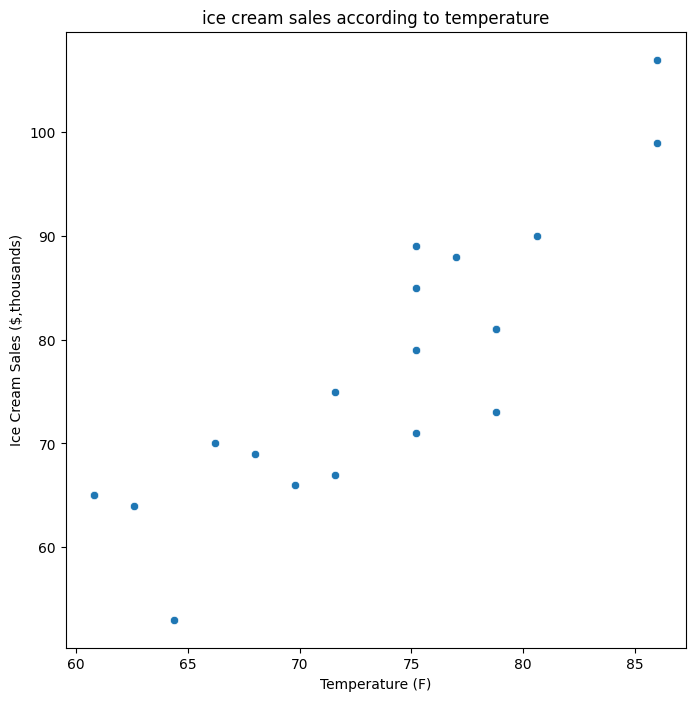

In [41]:
plt.figure(figsize=(8,8))
sns.scatterplot(df,x='Temperature (F)', y='Ice Cream Sales ($,thousands)', palette=['cyan','crimson'])
plt.title('ice cream sales according to temperature')
plt.show()

In [29]:
df['Did it rain on that day?']=df['Did it rain on that day?'].map({'Yes':1,'No':0})

In [30]:
x=df.drop(columns='Ice Cream Sales ($,thousands)')
y=df['Temperature (F)']

In [31]:
xtrain, xtest, ytrain, ytest= train_test_split(x,y, test_size=0.8, random_state=42)

In [32]:
model=LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# MODEL EVALUATION

In [34]:
#train data 
ytrain_pred=model.predict(xtrain)
train_score=r2_score(ytrain,ytrain_pred)
print(f'train score:{train_score}')

#test data
ytest_pred=model.predict(xtest)
test_score=r2_score(ytest,ytest_pred)
print(f'test score:{test_score}')

train score:1.0
test score:1.0


### linear regression creates the equation
### polynomial regession adds the extra features based on the degree, it is a pre-processing technique 
### sk learn linear regression uses OLS(ordinary least squares)

In [37]:
poly=PolynomialFeatures(degree=2)

In [ ]:
poly.fit_transform(xtrain) # we shouldn't use transform() directly beacause it will transform the values without learning the pattern. 
poly.transform(xtest)
# we use fit only for train data and we use transform only for test data.

array([[1.00000e+00, 8.06000e+01, 1.00000e+00, 8.95000e+01, 0.00000e+00,
        6.49636e+03, 8.06000e+01, 7.21370e+03, 0.00000e+00, 1.00000e+00,
        8.95000e+01, 0.00000e+00, 8.01025e+03, 0.00000e+00, 0.00000e+00],
       [1.00000e+00, 8.60000e+01, 7.50000e-01, 9.52000e+01, 0.00000e+00,
        7.39600e+03, 6.45000e+01, 8.18720e+03, 0.00000e+00, 5.62500e-01,
        7.14000e+01, 0.00000e+00, 9.06304e+03, 0.00000e+00, 0.00000e+00],
       [1.00000e+00, 6.44000e+01, 7.50000e-01, 5.21000e+01, 1.00000e+00,
        4.14736e+03, 4.83000e+01, 3.35524e+03, 6.44000e+01, 5.62500e-01,
        3.90750e+01, 7.50000e-01, 2.71441e+03, 5.21000e+01, 1.00000e+00],
       [1.00000e+00, 7.52000e+01, 1.00000e+00, 8.64000e+01, 0.00000e+00,
        5.65504e+03, 7.52000e+01, 6.49728e+03, 0.00000e+00, 1.00000e+00,
        8.64000e+01, 0.00000e+00, 7.46496e+03, 0.00000e+00, 0.00000e+00],
       [1.00000e+00, 6.08000e+01, 1.50000e+00, 6.94000e+01, 1.00000e+00,
        3.69664e+03, 9.12000e+01, 4.21952e+03, 